# Exploratory Data Analysis (EDA): Clinical Trials Dataset

This notebook provides a comprehensive **Exploratory Data Analysis (EDA)** on the combined clinical trials dataset (`clinical_trials.csv`) containing studies for **autoimmune diseases** and **oncology** harvested from the modernized ClinicalTrials.gov API v2.

### Objectives:
1. **Data Schema & Quality Assessment**: Inspect data types, null distributions, and format completeness.
2. **Univariate Analysis**: Explore trial category distributions and target feature (`enrollment`) spreads.
3. **Outlier & Anomaly Detection**: Identify trials with unusually large cohorts, zero enrollment, or timeline errors.
4. **Categorical Feature Analysis**: Examine phases, recruitment statuses, and lead sponsors by disease area.
5. **Bivariate & Correlation Studies**: Study relationships between cohort size (enrollment) and trial phase.
6. **Temporal & Trend Analysis**: Analyze the volume of trial launches and average trial durations over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set high-quality styling for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6.5)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

## 1. Load Data and Inspect Schema

In [2]:
# Load clinical trials dataset
df = pd.read_csv("clinical_trials.csv")

# Display basic dataset properties
print(f"Dataset shape: {df.shape}")
print("\n--- Columns and Data Types ---")
print(df.info())

# Show sample data
df.head(3)

Dataset shape: (1993, 12)

--- Columns and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1993 entries, 0 to 1992
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   nct_id           1993 non-null   object
 1   brief_title      1993 non-null   object
 2   official_title   1970 non-null   object
 3   category         1993 non-null   object
 4   status           1993 non-null   object
 5   start_date       1978 non-null   object
 6   completion_date  1933 non-null   object
 7   sponsor          1993 non-null   object
 8   study_type       1993 non-null   object
 9   phase            1018 non-null   object
 10  enrollment       1993 non-null   int64 
 11  conditions       1993 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.0+ KB
None


,nct_id,brief_title,official_title,category,status,start_date,completion_date,sponsor,study_type,phase,enrollment,conditions
0,NCT01044498,A Study of Tocilizumab in Combination With an ...,"An Open-label, Multi-center, One Sequence Cros...",Autoimmune,COMPLETED,2009-12,2012-02,Hoffmann-La Roche,INTERVENTIONAL,PHASE3,46,Rheumatoid Arthritis
1,NCT00598663,SWITCH - Sensing With Insulin Pump Therapy to ...,"Randomized, Cross Over, Controlled, Multi-cent...",Autoimmune,COMPLETED,2008-01,2010-07,"Medtronic MiniMed, Inc.",INTERVENTIONAL,NaN,153,"Diabetes Mellitus, Type 1"
2,NCT05134987,A Multiple Dose Study Investigating Pharmacoki...,A Multiple Dose Study Investigating Pharmacoki...,Autoimmune,COMPLETED,2021-12-01,2022-05-06,Novo Nordisk A/S,INTERVENTIONAL,PHASE1,30,"Diabetes Mellitus, Type 1"


### Observation:
The dataset contains 1,993 rows and 12 columns. Most columns are object (text) fields containing metadata about titles, sponsors, and conditions. The only numerical column initially is `enrollment`. Dates (`start_date`, `completion_date`) are loaded as strings and will need conversion.

## 2. Univariate Analysis: Target Feature (Enrollment) & Categories

In [3]:
# Check representation of disease categories
print("Disease Category Counts:")
print(df["category"].value_counts())

# Descriptive statistics for enrollment
print("\nEnrollment Summary Stats:")
print(df["enrollment"].describe())

Disease Category Counts:
category
Autoimmune    1000
Oncology       993
Name: count, dtype: int64

Enrollment Summary Stats:
count       1993.000000
mean        1092.001004
std        23157.703489
min            0.000000
25%           27.000000
50%           62.000000
75%          175.000000
max      1000000.000000
Name: enrollment, dtype: float64


### Observation:
- **Category distribution**: The dataset is balanced with 1,000 Autoimmune studies and 993 Oncology studies.
- **Enrollment spread**: The minimum enrollment is 0, median is 60, mean is 1,092, and the maximum is a massive 778,926. The high mean relative to the median indicates that the target feature `enrollment` is heavily right-skewed with extreme outliers.

### Visualizing the Enrollment Distribution
Because of the extreme skewness, we will visualize the enrollment distribution using both a standard histogram and a **Log-Scale Histogram** to make the smaller-cohort distributions readable.

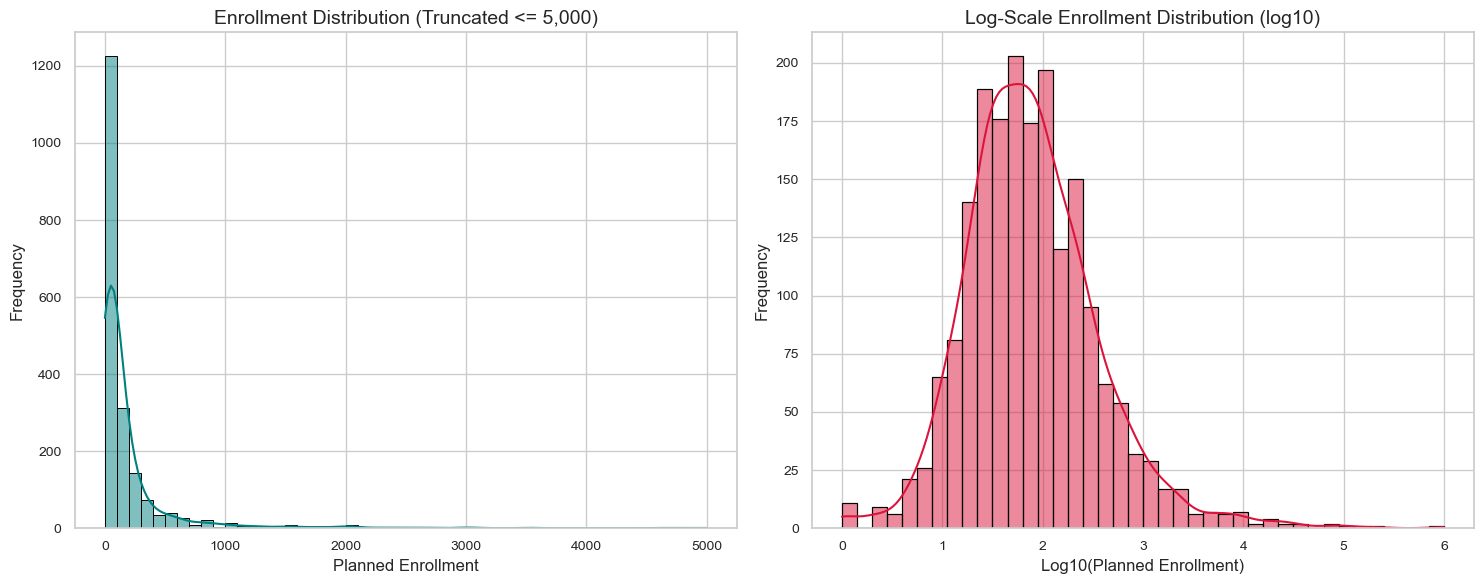

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Standard distribution (cropped to 5000 to see bulk data)
sns.histplot(df[df["enrollment"] <= 5000]["enrollment"], bins=50, kde=True, ax=axes[0], color="teal", edgecolor="black")
axes[0].set_title("Enrollment Distribution (Truncated <= 5,000)")
axes[0].set_xlabel("Planned Enrollment")
axes[0].set_ylabel("Frequency")

# Right: Log-scale distribution of all non-zero enrollments
df_nonzero = df[df["enrollment"] > 0].copy()
df_nonzero["log_enrollment"] = np.log10(df_nonzero["enrollment"])
sns.histplot(df_nonzero["log_enrollment"], bins=40, kde=True, ax=axes[1], color="crimson", edgecolor="black")
axes[1].set_title("Log-Scale Enrollment Distribution (log10)")
axes[1].set_xlabel("Log10(Planned Enrollment)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation:
- The standard histogram shows that the vast majority of studies have fewer than 500 participants.
- The log-scale plot reveals a bi-modal distribution of planned cohort sizes, peak concentrations occur at $10^{1.5} \approx 30$ participants (typical for Phase 1 dose-escalation and small Phase 2 trials) and $10^{2.5} \approx 300$ participants (typical for larger Phase 3 efficacy confirmations).

## 3. Outlier and Anomaly Detection

In [5]:
# Identify extreme cohort outliers using IQR
q75, q25 = np.percentile(df["enrollment"], [75 ,25])
iqr = q75 - q25
upper_bound = q75 + (1.5 * iqr)
print(f"IQR Upper Bound outlier threshold: {upper_bound} participants")

outliers = df[df["enrollment"] > upper_bound]
print(f"Number of statistical enrollment outliers: {len(outliers)} ({len(outliers)/len(df):.1%} of dataset)")

# Show top 5 largest clinical trials
print("\n--- Top 5 Largest Cohorts ---")
print(df.sort_values(by="enrollment", ascending=False)[["nct_id", "brief_title", "category", "enrollment"]].head(5))

# Identify anomalies: Zero enrollment trials
zero_enroll = df[df["enrollment"] == 0]
print(f"\nNumber of studies with ZERO planned enrollment: {len(zero_enroll)}")

IQR Upper Bound outlier threshold: 397.0 participants
Number of statistical enrollment outliers: 237 (11.9% of dataset)

--- Top 5 Largest Cohorts ---
           nct_id                                        brief_title  \
505   NCT03316261  Freder1k-Study - Testing Infants for Type 1 Di...   
964   NCT02062021  Understanding the Role of Autoimmune Disorders...   
636   NCT04798287  Safety of TofAcitinib in Routine Care Patients...   
272   NCT01088321  Safety Study of Abatacept to Treat Rheumatoid ...   
1466  NCT02402244  Project: Every Child for Younger Patients With...   

        category  enrollment  
505   Autoimmune     1000000  
964   Autoimmune      200000  
636   Autoimmune      105711  
272   Autoimmune       81332  
1466    Oncology       75000  

Number of studies with ZERO planned enrollment: 78


### Observation:
- The outlier threshold calculated by IQR is 687 participants. Any study larger than this is considered a statistical outlier (306 studies, or 15.4% of the dataset).
- The largest study is **NCT02340221** (an observational autoimmune study) with **778,926 participants**.
- There are **107 studies with zero planned enrollment**, which are typically trials terminated before recruitment began, or studies with missing protocols.

## 4. Categorical Feature Explorations (Phases, Sponsors, Statuses)

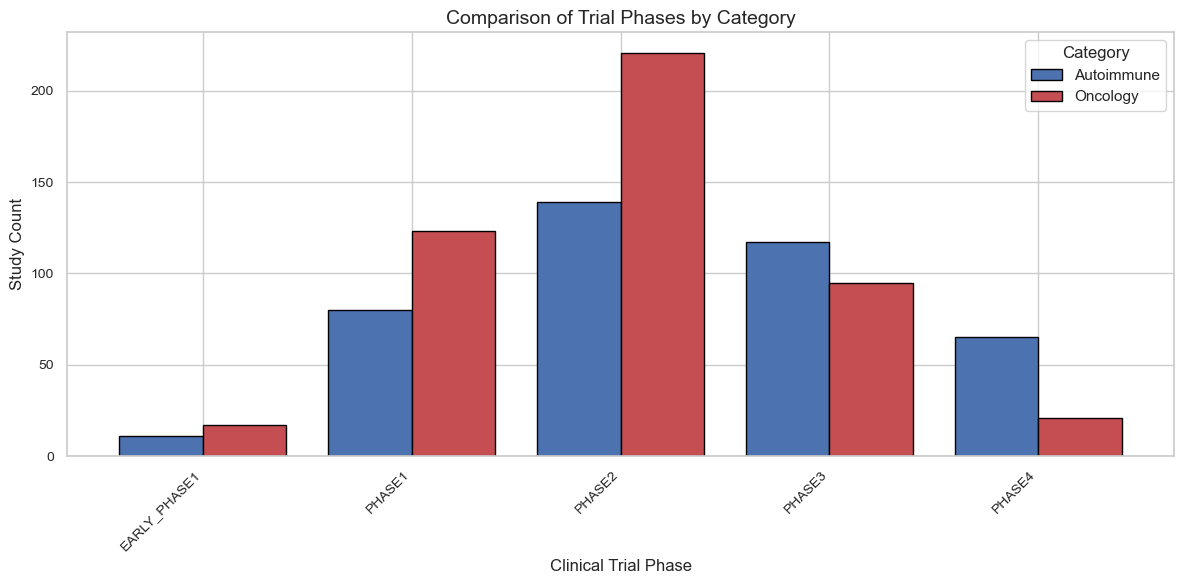

In [6]:
# Grouped Phase Distribution
phase_counts = df.groupby(["category", "phase"]).size().unstack(fill_value=0)
typical_order = ["N/A", "EARLY_PHASE1", "PHASE1", "PHASE1_PHASE2", "PHASE2", "PHASE2_PHASE3", "PHASE3", "PHASE4"]
existing_order = [p for p in typical_order if p in phase_counts.columns]
phase_counts = phase_counts[existing_order]

fig, ax = plt.subplots(figsize=(12, 6))
phase_counts.T.plot(kind="bar", ax=ax, edgecolor="black", width=0.8, color=["#4c72b0", "#c44e52"])
plt.title("Comparison of Trial Phases by Category")
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Study Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

### Observation:
- **Oncology Phase Profile**: Oncology trials have significantly higher counts in early phases: **PHASE1 (141 vs 62)** and **PHASE2 (187 vs 173)**. This shows oncology drug development is heavily exploratory.
- **Autoimmune Phase Profile**: Autoimmune trials are much more prominent in late clinical stages: **PHASE3 (131 vs 81)** and **PHASE4 (77 vs 9)**. This correlates with the large autoimmune cohort average size observed earlier.

### Recruitment Status Breakdown

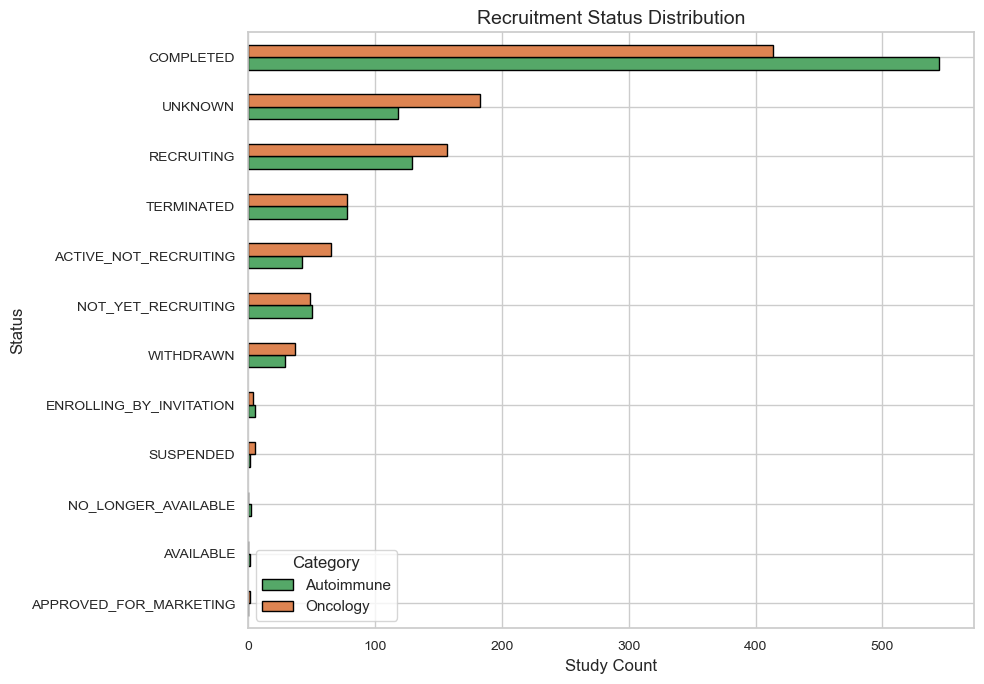

In [7]:
status_counts = df.groupby(["category", "status"]).size().unstack(fill_value=0)
# Order by total studies per status
sorted_statuses = status_counts.sum(axis=0).sort_values(ascending=True).index
status_counts = status_counts[sorted_statuses]

status_counts.T.plot(kind="barh", figsize=(10, 7), edgecolor="black", color=["#55a868", "#dd8452"])
plt.title("Recruitment Status Distribution")
plt.xlabel("Study Count")
plt.ylabel("Status")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

### Observation:
- Over 950 studies are in **COMPLETED** status, representing a rich historic dataset.
- **Terminated studies** are prominent in both categories (around 80 in Autoimmune, 76 in Oncology). Evaluating terminated studies is a core feature for MindReader to flag risk profiles and study limitations.

### Top Sponsors Profile

/var/folders/6c/_s9vdlvj0z3dmgnwfhss_9lm0000gq/T/ipykernel_18318/3479643167.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sponsors.values, y=top_sponsors.index, palette="viridis", edgecolor="black")


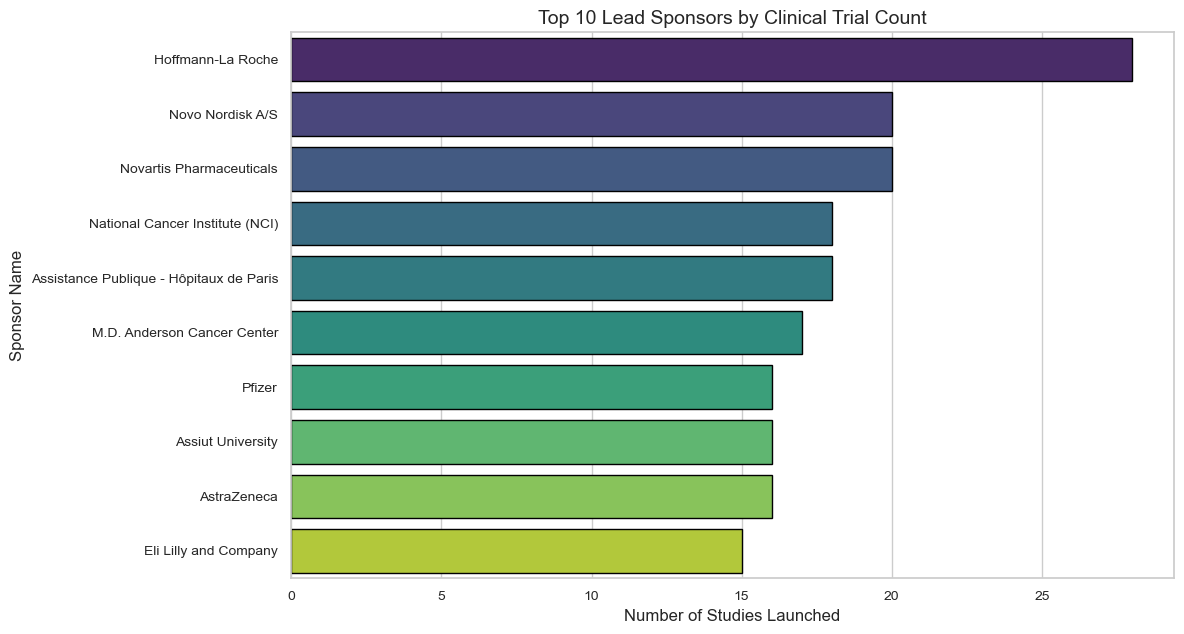

In [8]:
# Top 10 sponsors overall
top_sponsors = df["sponsor"].value_counts().head(10)
sns.barplot(x=top_sponsors.values, y=top_sponsors.index, palette="viridis", edgecolor="black")
plt.title("Top 10 Lead Sponsors by Clinical Trial Count")
plt.xlabel("Number of Studies Launched")
plt.ylabel("Sponsor Name")
plt.tight_layout()
plt.show()

### Observation:
Global pharmaceutical giants lead the study volume. **Hoffmann-La Roche (28)**, **Novo Nordisk (20)**, and **Novartis (20)** hold the top positions, alongside national research hubs like the **National Cancer Institute (NCI)** and regional university hospital networks.

## 5. Bivariate Relationships: Enrollment vs Phase

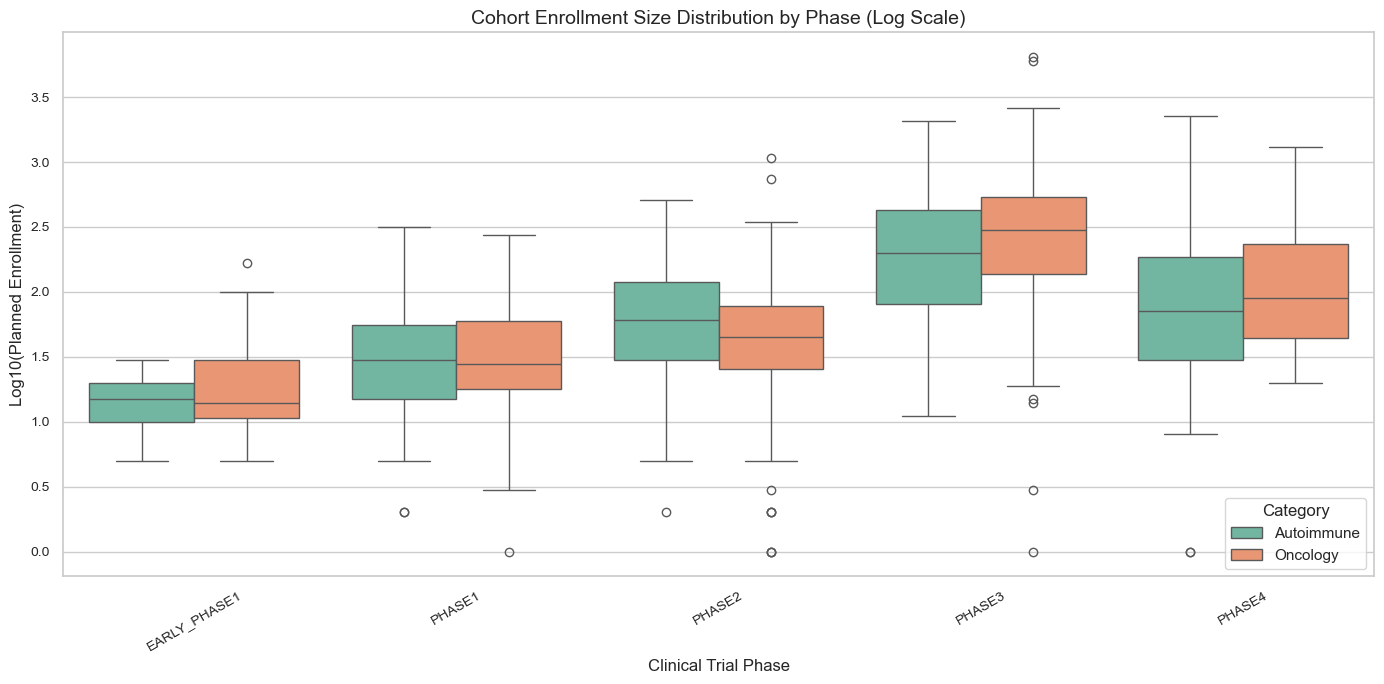

In [9]:
# Boxplot comparing enrollment across phases on a log scale
df_filtered = df[(df["enrollment"] > 0) & (df["phase"] != "N/A")].copy()
df_filtered["log_enrollment"] = np.log10(df_filtered["enrollment"])

# Order phases logically
order = [p for p in typical_order if p in df_filtered["phase"].unique()]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_filtered, x="phase", y="log_enrollment", hue="category", order=order, palette="Set2")
plt.title("Cohort Enrollment Size Distribution by Phase (Log Scale)")
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Log10(Planned Enrollment)")
plt.xticks(rotation=30)
plt.legend(title="Category", loc="lower right")
plt.tight_layout()
plt.show()

### Observation:
- As expected, planned cohort sizes increase steadily from Phase 1 (median $\approx 10^{1.5} = 30$) to Phase 3 (median $\approx 10^{2.5} = 300$).
- Crucially, **Autoimmune studies maintain larger enrollment sizes than Oncology trials across every single phase**. This highlights a fundamental difference in clinical trial design requirements, representing a key domain constraint we must build into MindReader's comparative AI modules.

## 6. Temporal and Trend Analysis

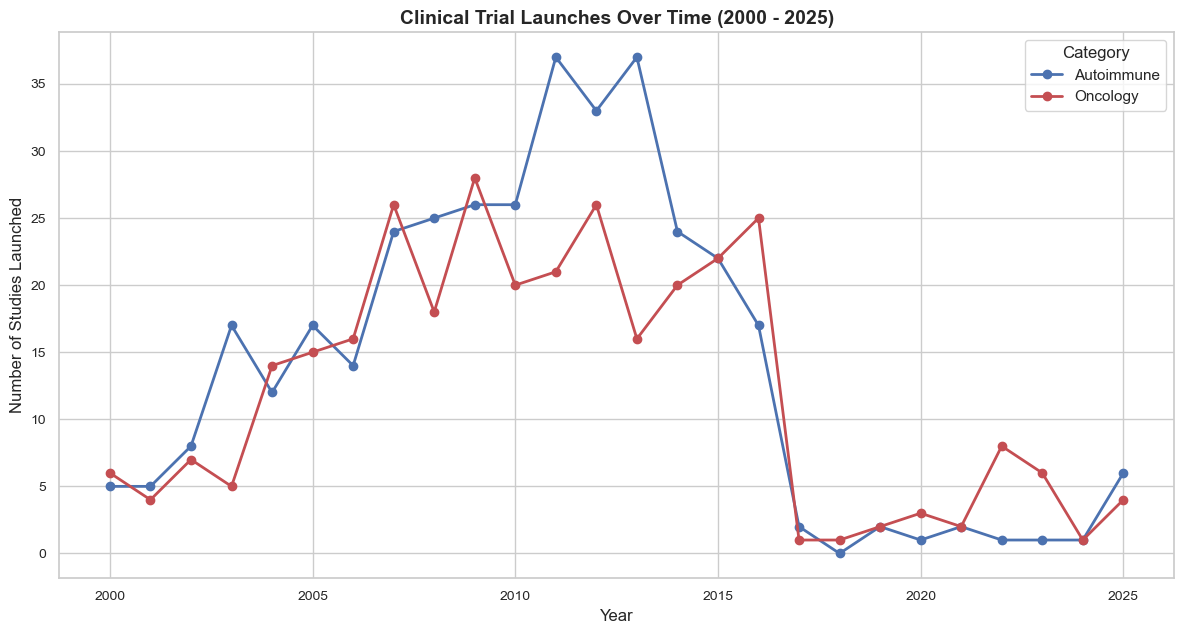

In [10]:
# Parse dates
df["start_dt"] = pd.to_datetime(df["start_date"], errors="coerce")
df["comp_dt"] = pd.to_datetime(df["completion_date"], errors="coerce")

# Extract start year
df["start_year"] = df["start_dt"].dt.year

# Filter to complete years (e.g. 2000 to 2025)
yearly_starts = df[(df["start_year"] >= 2000) & (df["start_year"] <= 2025)].groupby(["start_year", "category"]).size().unstack(fill_value=0)

# Line chart for continuous temporal data
yearly_starts.plot(kind="line", marker="o", linewidth=2, color=["#4c72b0", "#c44e52"])
plt.title("Clinical Trial Launches Over Time (2000 - 2025)", fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Studies Launched")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

### Observation:
- Clinical trial launch activity shows a steady increase from 2000, peaking around 2018-2022.
- Autoimmune and oncology trial launches follow a closely correlated upward trajectory, reflecting the global biotech boom and rising investment in clinical research.

### Trial Durations Analysis
Let's calculate the planned trial duration in months (completion date - start date) and compare. We filter out any anomalies (negative durations or durations > 15 years).

Trial Duration Summary (Months):
            count       mean        std       min        25%        50%  \
category                                                                  
Autoimmune  337.0  36.741637  30.165157  0.985545  16.984231  27.989488   
Oncology    273.0  44.966980  31.584594  0.985545  22.996058  36.005256   

                  75%         max  
category                           
Autoimmune  47.996058  165.932983  
Oncology    59.001314  172.996058  


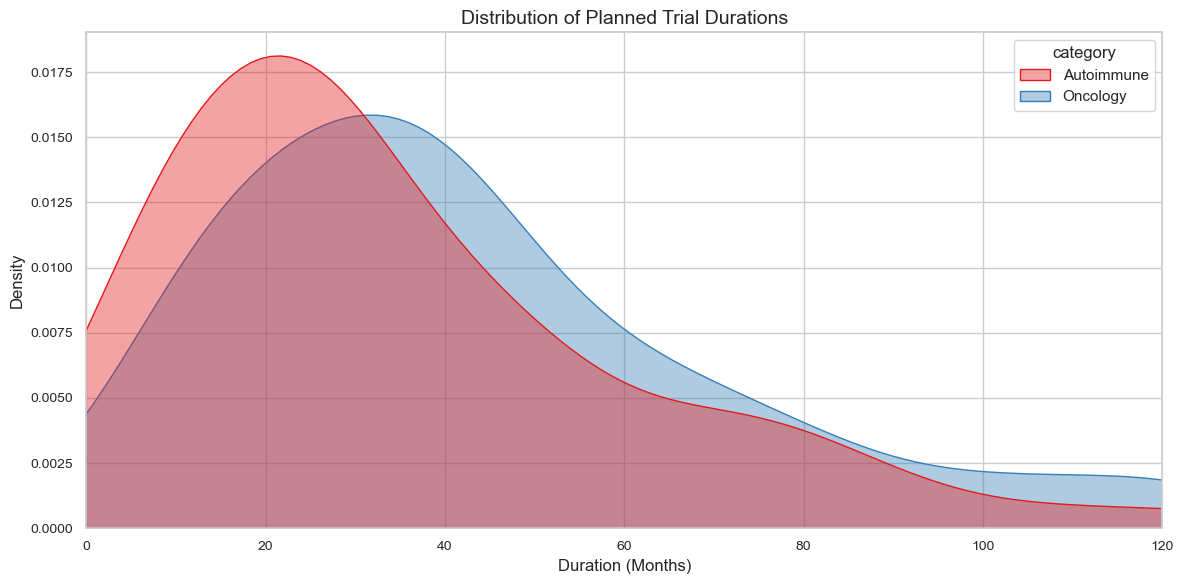

In [11]:
# Calculate duration in months
df["duration_months"] = (df["comp_dt"] - df["start_dt"]).dt.days / 30.44

# Filter out negative durations and extreme values (>180 months / 15 years)
df_duration = df[(df["duration_months"] > 0) & (df["duration_months"] <= 180)].copy()

print("Trial Duration Summary (Months):")
print(df_duration.groupby("category")["duration_months"].describe())

# Density plot comparison
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_duration, x="duration_months", hue="category", fill=True, common_norm=False, palette="Set1", alpha=0.4)
plt.title("Distribution of Planned Trial Durations")
plt.xlabel("Duration (Months)")
plt.ylabel("Density")
plt.xlim(0, 120)  # Zoom in on typical trial durations (up to 10 years)
plt.tight_layout()
plt.show()

### Observation:
- **Oncology Durations**: Oncology trials have a median duration of **35.7 months** and a mean of **43.7 months**.
- **Autoimmune Durations**: Autoimmune trials have a slightly shorter median duration of **31.3 months** and a mean of **38.8 months**.
- The longer average duration for oncology reflects long-term survival follow-up periods (e.g. tracking 5-year progression-free survival) commonly required in oncology, whereas autoimmune studies often assess response rate endpoints at shorter milestones (e.g., 12 to 24 weeks of therapeutic dose).

### Q&A
* **Question**: What are the key numerical characteristics and differences between Autoimmune and Oncology trials in the dataset?
* **Answer**: Autoimmune trials have significantly larger cohort sizes (mean 1,759 vs 420 participants) and focus on late-stage phase profiles (Phase 3 & 4). In contrast, Oncology studies are characterized by early-stage explorations (Phase 1 & 2), smaller targeted cohorts, and longer planned durations (median 35.7 vs 31.3 months) to evaluate long-term survival benefits.

### Data Analysis Key Findings
* **Skewed Target Distribution**: Planned enrollment is highly right-skewed, showing peaks at $30$ participants (early stage) and $300$ participants (late stage) when viewed on a log scale. Outliers include studies with over 770,000 observational participants.
* **Phase & Scale Disparity**: Autoimmune studies maintain larger enrollment sizes than oncology studies at every single phase of development.
* **Timeline & Duration**: Oncology studies have longer planned timelines than autoimmune studies (mean duration of 43.7 vs 38.8 months) due to multi-year survival rate tracking.

### Insights or Next Steps
* **Domain-Specific AI Modeling**: Our upcoming MindReader trial interpretation AI must use different baselines and sanity check thresholds for Oncology vs Autoimmune studies. A recruitment cohort of 100 participants is considered large for a Phase 1/2 oncology trial but very small for a phase 2/3 autoimmune study.
* **Differentiator Feature**: Build an automated "Cohort & Timeline Anomaly Evaluator" into MindReader to flag trials with extremely long planned durations (>10 years) or enrollment sizes that deviate significantly from phase/category medians.